<a href="https://colab.research.google.com/github/codexnyctis/104520751_concept4/blob/dev%2Fnur%2FPrediction/Processor_Usage_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Setup and Library Imports

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# - pandas and numpy: for data manipulation and numerical operations
# - sklearn: for data preprocessing and evaluation metrics
# - tensorflow.keras: for building and training the neural network
# - matplotlib: for creating visualizations
# - joblib: for saving and loading Python objects

## 2. Data Loading and Preprocessing

Explanation:
- We define a function `clean_processor_time` to handle various data inconsistencies in the 'Processor_pct_ Processor_Time' column.
- The data is loaded from a CSV file, and the timestamp column is converted to datetime format.
- We clean the 'Processor_pct_ Processor_Time' column and remove any rows with NaN values.
- The data is resampled to hourly intervals, taking the mean for each hour, and any missing values are interpolated.


In [ ]:
# Load and preprocess data
df = pd.read_csv('windows10_dataset.csv')
df['ts'] = pd.to_datetime(df['ts'], unit='s')
df.set_index('ts', inplace=True)

# Clean the 'Processor_pct_ Processor_Time' column
def clean_processor_time(value):
    if pd.isna(value) or str(value).strip() == '':
        return np.nan
    try:
        return float(value)
    except ValueError:
        try:
            values = [float(v) for v in str(value).split('.') if v.strip()]
            return sum(values) / len(values) if values else np.nan
        except ValueError:
            return np.nan

df['Processor_pct_ Processor_Time'] = df['Processor_pct_ Processor_Time'].apply(clean_processor_time)
df = df.dropna(subset=['Processor_pct_ Processor_Time'])

# Resample to hourly data and handle any remaining NaNs
df_hourly = df['Processor_pct_ Processor_Time'].resample('1h').mean().interpolate()

# Check for any remaining NaNs
if df_hourly.isnull().sum() > 0:
    print(f"Warning: {df_hourly.isnull().sum()} NaN values remain after interpolation.")
    df_hourly = df_hourly.dropna()

## 3. Data Normalization and Sequence Creation

Explanation:
- We use MinMaxScaler to normalize our data to a range between 0 and 1. This helps in model convergence.
- The `create_sequences` function creates input-output pairs for our model. Each input is a sequence of 24 hours, and the output is the next hour's value.

In [ ]:
# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df_hourly.values.reshape(-1, 1))

# Create sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:(i + seq_length), 0])
        y.append(data[i + seq_length, 0])
    return np.array(X), np.array(y)

seq_length = 24  # Use 24 hours of data to predict the next hour
X, y = create_sequences(scaled_data, seq_length)

## 4. Splitting Data into Training and Testing Sets

Explanation:
- We use 80% of our data for training and 20% for testing.
- The data is reshaped to fit the input shape expected by LSTM layers: (samples, time steps, features).

In [ ]:
# Split into train and test sets
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Reshape input to be [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

## 5. Building and Training the LSTM Model

Explanation:
- We create a Sequential model with two LSTM layers and a Dense output layer.
- The model is compiled with Adam optimizer and Mean Squared Error (MSE) as the loss function.
- We train the model for 50 epochs, with a batch size of 32, and use 20% of the training data for validation.

In [ ]:
# Build the LSTM model
model = Sequential([
    LSTM(50, activation='relu', input_shape=(X_train.shape[1], 1), return_sequences=True),
    LSTM(50, activation='relu'),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - loss: 0.0635 - val_loss: 0.0355
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0092 - val_loss: 0.0239
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0062 - val_loss: 0.0168
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0034 - val_loss: 0.0156
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0039 - val_loss: 0.0157
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0029 - val_loss: 0.0167
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0021 - val_loss: 0.0160
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0026 - val_loss: 0.0164
Epoch 9/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0023 - val_loss: 0.0172
Epoch 10/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0025 - val_loss: 0.0169
Epoch 11/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.0034 - val_loss: 0.0156
Epoch 12/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0

## 6. Making Predictions and Calculating Error

Explanation:
- We make predictions on both training and test data.
- The predictions are inverse transformed to the original scale.
- We calculate the Root Mean Square Error (RMSE) for both training and test sets to evaluate model performance.

In [ ]:
# Make predictions
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Invert predictions to original scale
train_predict = scaler.inverse_transform(train_predict)
y_train_inv = scaler.inverse_transform(y_train.reshape(-1, 1))
test_predict = scaler.inverse_transform(test_predict)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate RMSE
train_rmse = np.sqrt(mean_squared_error(y_train_inv, train_predict))
test_rmse = np.sqrt(mean_squared_error(y_test_inv, test_predict))
print(f'Train RMSE: {train_rmse}')
print(f'Test RMSE: {test_rmse}')

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Train RMSE: 4.813218644219161
Test RMSE: 17.915402101976106


## 7. Visualizing Results

Explanation:
- We create three plots: one for training set predictions, one for test set predictions, and one showing the training history.
- These visualizations help us understand how well our model is performing and if there's any overfitting.

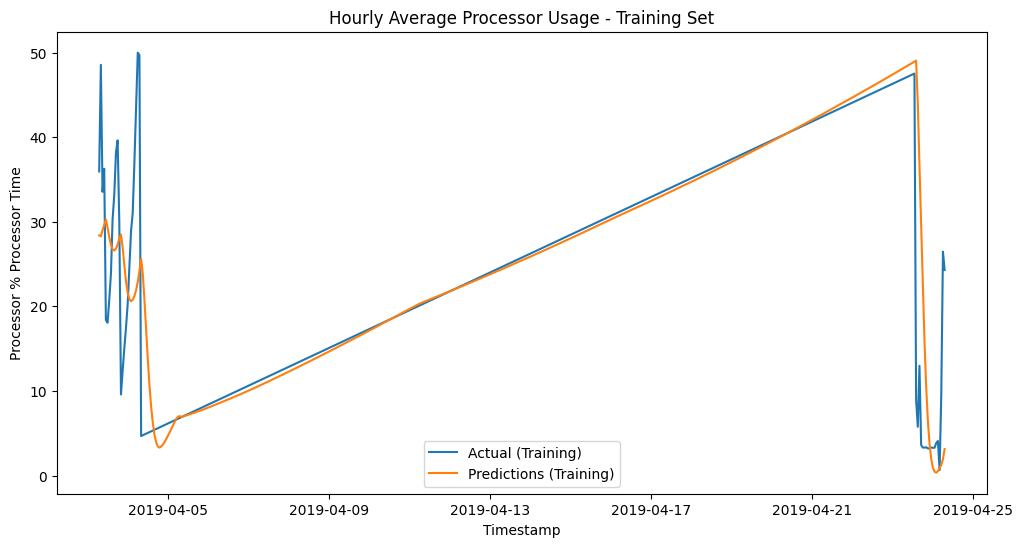

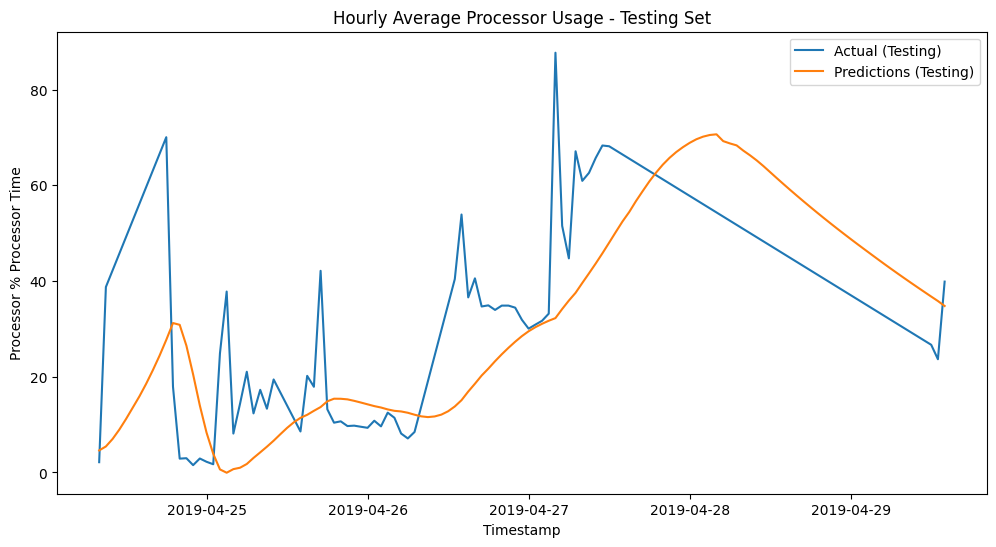

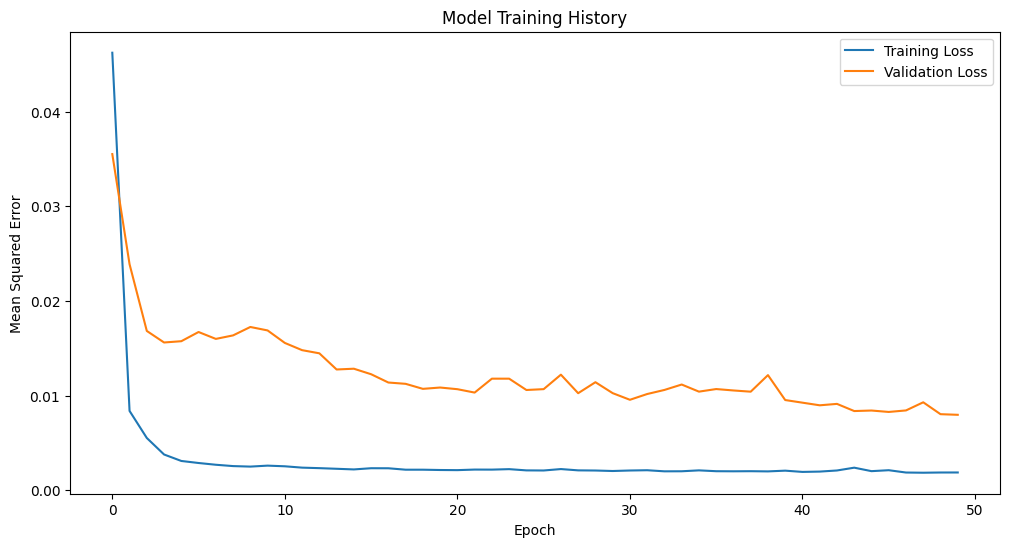

In [ ]:
# Plot results for training set
plt.figure(figsize=(12, 6))
plt.plot(df_hourly.index[seq_length:train_size+seq_length], y_train_inv, label='Actual (Training)')
plt.plot(df_hourly.index[seq_length:train_size+seq_length], train_predict, label='Predictions (Training)')
plt.xlabel('Timestamp')
plt.ylabel('Processor % Processor Time')
plt.title('Hourly Average Processor Usage - Training Set')
plt.legend()
plt.show()

# Plot results for testing set
plt.figure(figsize=(12, 6))
plt.plot(df_hourly.index[train_size+seq_length:], y_test_inv, label='Actual (Testing)')
plt.plot(df_hourly.index[train_size+seq_length:], test_predict, label='Predictions (Testing)')
plt.xlabel('Timestamp')
plt.ylabel('Processor % Processor Time')
plt.title('Hourly Average Processor Usage - Testing Set')
plt.legend()
plt.show()

# Plot training history
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('Model Training History')
plt.legend()
plt.show()

## 8. Saving the Model and Data

Explanation:
- We save the trained model, the scaler used for normalization, and the processed hourly data.
- This allows us to use the model for predictions later without having to retrain it.

In [ ]:
# Save the trained model
model.save('lstm_model.h5')
print("Model saved as 'lstm_model.h5'")

# Import joblib
import joblib

# Save the scaler
joblib.dump(scaler, 'scaler.pkl')
print("Scaler saved as 'scaler.pkl'")

# Save the hourly data
df_hourly.to_csv('hourly_data.csv')
print("Hourly data saved as 'hourly_data.csv'")

Model saved as 'lstm_model.h5'
Scaler saved as 'scaler.pkl'
Hourly data saved as 'hourly_data.csv'


## 9. Making Future Predictions

Explanation:
- We define a function to make predictions for a single time step.
- We use the last 7 days of data and predict the next 24 hours.
- The predictions are plotted alongside the last 7 days of actual data.
- Finally, we print out the specific predictions for each future hour.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


<ipython-input-20-8e3dde6097ea>:21: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  prediction_dates = pd.date_range(start=last_7_days.index[-1] + pd.Timedelta(hours=1), periods=24, freq='H')


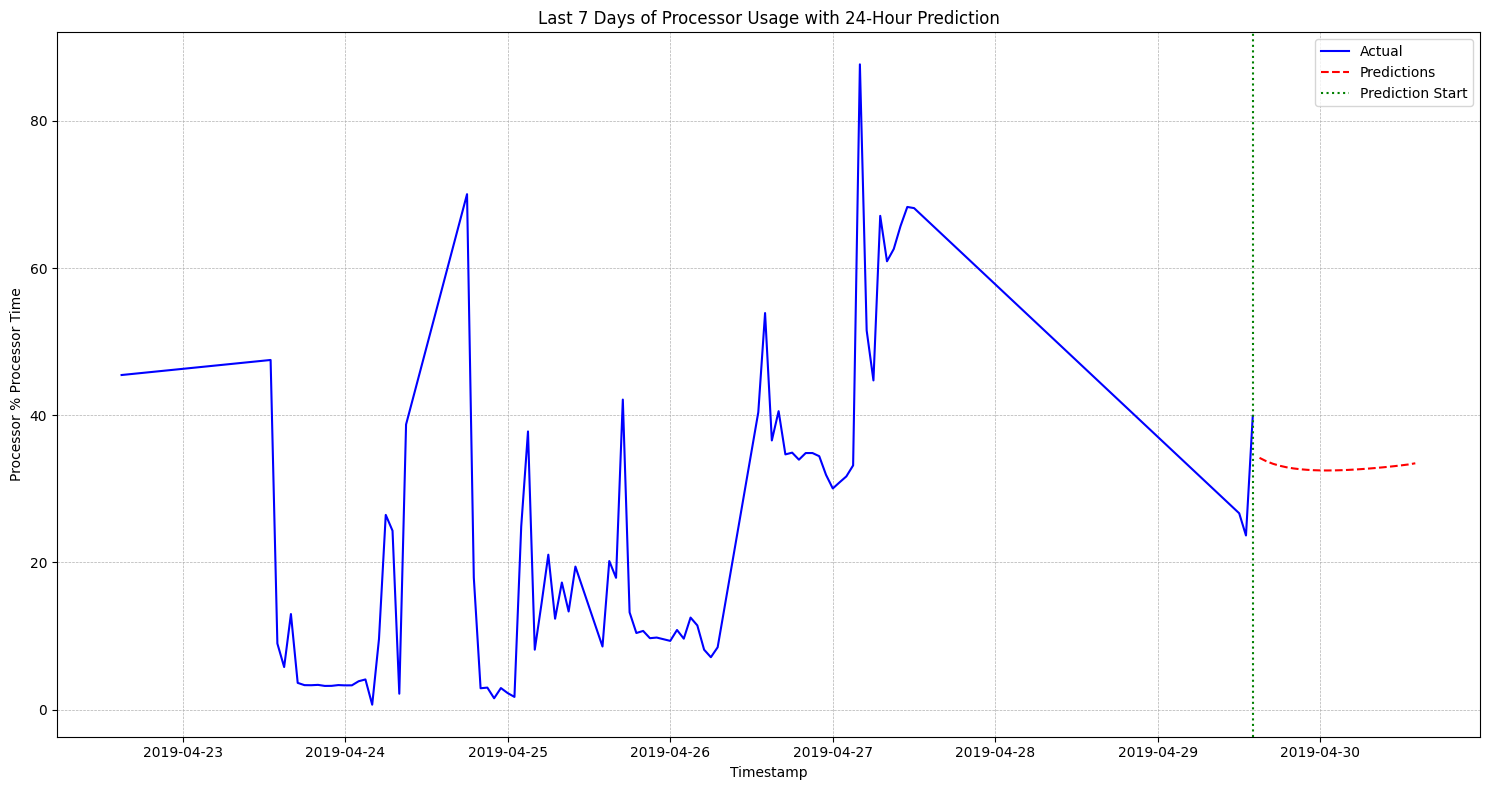

Predicted Processor % Processor Time for 2019-04-29 15:00:00: 34.21%
Predicted Processor % Processor Time for 2019-04-29 16:00:00: 33.75%
Predicted Processor % Processor Time for 2019-04-29 17:00:00: 33.40%
Predicted Processor % Processor Time for 2019-04-29 18:00:00: 33.13%
Predicted Processor % Processor Time for 2019-04-29 19:00:00: 32.92%
Predicted Processor % Processor Time for 2019-04-29 20:00:00: 32.77%
Predicted Processor % Processor Time for 2019-04-29 21:00:00: 32.66%
Predicted Processor % Processor Time for 2019-04-29 22:00:00: 32.58%
Predicted Processor % Processor Time for 2019-04-29 23:00:00: 32.53%
Predicted Processor % Processor Time for 2019-04-30 00:00:00: 32.50%
Predicted Processor % Processor Time for 2019-04-30 01:00:00: 32.49%
Predicted Processor % Processor Time for 2019-04-30 02:00:00: 32.50%
Predicted Processor % Processor Time for 2019-04-30 03:00:00: 32.53%
Predicted Processor % Processor Time for 2019-04-30 04:00:00: 32.57%
Predicted Processor % Processor Ti

In [ ]:
# Function to make predictions
def make_prediction(last_24_hours):
    last_24_hours_scaled = scaler.transform(last_24_hours.reshape(-1, 1))
    X_next = last_24_hours_scaled.reshape(1, 24, 1)
    next_hour_scaled = model.predict(X_next)
    return scaler.inverse_transform(next_hour_scaled)[0][0]

# Get the last 7 days of data
last_7_days = df_hourly[-168:]

# Make predictions for the next 24 hours
predictions = []
last_24_hours = last_7_days[-24:].values

for _ in range(24):
    next_hour = make_prediction(last_24_hours)
    predictions.append(next_hour)
    last_24_hours = np.append(last_24_hours[1:], next_hour)

# Create a date range for the predictions
prediction_dates = pd.date_range(start=last_7_days.index[-1] + pd.Timedelta(hours=1), periods=24, freq='H')


# Plot
plt.figure(figsize=(15, 8))
plt.plot(last_7_days.index, last_7_days.values, label='Actual', color='blue')
plt.plot(prediction_dates, predictions, label='Predictions', color='red', linestyle='--')
plt.axvline(x=last_7_days.index[-1], color='green', linestyle=':', label='Prediction Start')
plt.xlabel('Timestamp')
plt.ylabel('Processor % Processor Time')
plt.title('Last 7 Days of Processor Usage with 24-Hour Prediction')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

# Print the predictions
for date, prediction in zip(prediction_dates, predictions):
    print(f"Predicted Processor % Processor Time for {date}: {prediction:.2f}%")